# EEG - dDTF - Analysis Pipeline

In [ ]:
# Requirements
%pip install mne numpy matplotlib

In [2]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

Data is downloaded via CyberDuck.

In [3]:
os.chdir('c:\\Users\\Einez (School)\\Desktop\\Chang_EEG_LEMON\\EEG_Preprocessed')
os.getcwd()

'c:\\Users\\Einez (School)\\Desktop\\Chang_EEG_LEMON\\EEG_Preprocessed'

# Organize by Subjects

In [4]:
# no outlier in time length
ID = ['sub-010002', 'sub-010003', 'sub-010004', 'sub-010005', 'sub-010006', 'sub-010007', 'sub-010010', 'sub-010012', 'sub-010016', 'sub-010017', 'sub-010019', 'sub-010020', 'sub-010021', 'sub-010022', 'sub-010023', 'sub-010024', 'sub-010026', 'sub-010027', 'sub-010028', 'sub-010029', 'sub-010030', 'sub-010031', 'sub-010032', 'sub-010033', 'sub-010034', 'sub-010035', 'sub-010036', 'sub-010037', 'sub-010038', 'sub-010039', 'sub-010040', 'sub-010041', 'sub-010042', 'sub-010044', 'sub-010045', 'sub-010046', 'sub-010047', 'sub-010048', 'sub-010049', 'sub-010050', 'sub-010051', 'sub-010052', 'sub-010053', 'sub-010056', 'sub-010059', 'sub-010060', 'sub-010061', 'sub-010062', 'sub-010063', 'sub-010064', 'sub-010065', 'sub-010066', 'sub-010067', 'sub-010068', 'sub-010069', 'sub-010070', 'sub-010071', 'sub-010072', 'sub-010073', 'sub-010074', 'sub-010075', 'sub-010076', 'sub-010079', 'sub-010080', 'sub-010081', 'sub-010083', 'sub-010084', 'sub-010085', 'sub-010086', 'sub-010088', 'sub-010089', 'sub-010090', 'sub-010091', 'sub-010092', 'sub-010093', 'sub-010094', 'sub-010104', 'sub-010126', 'sub-010134', 'sub-010136', 'sub-010137', 'sub-010138', 'sub-010141', 'sub-010142', 'sub-010146', 'sub-010148', 'sub-010150', 'sub-010152', 'sub-010155', 'sub-010157', 'sub-010162', 'sub-010163', 'sub-010164', 'sub-010165', 'sub-010166', 'sub-010168', 'sub-010170', 'sub-010176', 'sub-010183', 'sub-010191', 'sub-010192', 'sub-010194', 'sub-010195', 'sub-010196', 'sub-010197', 'sub-010199', 'sub-010200', 'sub-010201', 'sub-010202', 'sub-010204', 'sub-010207', 'sub-010210', 'sub-010213', 'sub-010214', 'sub-010215', 'sub-010218', 'sub-010219', 'sub-010220', 'sub-010222', 'sub-010223', 'sub-010224', 'sub-010226', 'sub-010227', 'sub-010228', 'sub-010229', 'sub-010230', 'sub-010231', 'sub-010232', 'sub-010233', 'sub-010234', 'sub-010236', 'sub-010238', 'sub-010239', 'sub-010240', 'sub-010241', 'sub-010242', 'sub-010243', 'sub-010244', 'sub-010245', 'sub-010246', 'sub-010247', 'sub-010248', 'sub-010249', 'sub-010250', 'sub-010251', 'sub-010252', 'sub-010254', 'sub-010255', 'sub-010256', 'sub-010257', 'sub-010258', 'sub-010260', 'sub-010261', 'sub-010262', 'sub-010263', 'sub-010264', 'sub-010265', 'sub-010266', 'sub-010267', 'sub-010268', 'sub-010269', 'sub-010270', 'sub-010271', 'sub-010272', 'sub-010273', 'sub-010274', 'sub-010275', 'sub-010283', 'sub-010284', 'sub-010286', 'sub-010287', 'sub-010288', 'sub-010289', 'sub-010290', 'sub-010291', 'sub-010292', 'sub-010294', 'sub-010295', 'sub-010296', 'sub-010297', 'sub-010298', 'sub-010299', 'sub-010300', 'sub-010301', 'sub-010302', 'sub-010303', 'sub-010304', 'sub-010305', 'sub-010306', 'sub-010307', 'sub-010308', 'sub-010309', 'sub-010310', 'sub-010311', 'sub-010314', 'sub-010315', 'sub-010316', 'sub-010317', 'sub-010318', 'sub-010319', 'sub-010321']


In [5]:
# ID = ['sub-010002', 'sub-010003', 'sub-010004', 'sub-010005', 'sub-010006', 'sub-010007', 'sub-010010', 'sub-010012', 'sub-010016', 'sub-010017', 'sub-010019', 'sub-010020', 'sub-010021', 'sub-010022', 'sub-010023', 'sub-010024', 'sub-010026', 'sub-010027', 'sub-010028', 'sub-010029', 'sub-010030', 'sub-010031', 'sub-010032', 'sub-010033', 'sub-010034', 'sub-010035', 'sub-010036', 'sub-010037', 'sub-010038', 'sub-010039', 'sub-010040', 'sub-010041', 'sub-010042', 'sub-010044', 'sub-010045', 'sub-010046', 'sub-010047', 'sub-010048', 'sub-010049', 'sub-010050', 'sub-010051', 'sub-010052', 'sub-010053', 'sub-010056', 'sub-010059', 'sub-010060', 'sub-010061', 'sub-010062', 'sub-010063', 'sub-010064', 'sub-010065', 'sub-010066', 'sub-010067', 'sub-010068', 'sub-010069', 'sub-010070', 'sub-010071', 'sub-010072', 'sub-010073', 'sub-010074', 'sub-010075', 'sub-010076', 'sub-010079', 'sub-010080', 'sub-010081', 'sub-010083', 'sub-010084', 'sub-010085', 'sub-010086', 'sub-010088', 'sub-010089', 'sub-010090', 'sub-010091', 'sub-010092', 'sub-010093', 'sub-010094', 'sub-010104', 'sub-010126', 'sub-010134', 'sub-010136', 'sub-010137', 'sub-010138', 'sub-010141', 'sub-010142', 'sub-010146', 'sub-010148', 'sub-010150', 'sub-010152', 'sub-010155', 'sub-010157', 'sub-010162', 'sub-010163', 'sub-010164', 'sub-010165', 'sub-010166', 'sub-010168', 'sub-010170', 'sub-010176', 'sub-010183', 'sub-010191', 'sub-010192', 'sub-010194', 'sub-010195', 'sub-010196', 'sub-010197', 'sub-010199', 'sub-010200', 'sub-010201', 'sub-010202', 'sub-010204', 'sub-010207', 'sub-010210', 'sub-010213', 'sub-010214', 'sub-010215', 'sub-010218', 'sub-010219', 'sub-010220', 'sub-010222', 'sub-010223', 'sub-010224', 'sub-010226', 'sub-010227', 'sub-010228', 'sub-010229', 'sub-010230', 'sub-010231', 'sub-010232', 'sub-010233', 'sub-010234', 'sub-010236', 'sub-010238', 'sub-010239', 'sub-010240', 'sub-010241', 'sub-010242', 'sub-010243', 'sub-010244', 'sub-010245', 'sub-010246', 'sub-010247', 'sub-010248', 'sub-010249', 'sub-010250', 'sub-010251', 'sub-010252', 'sub-010254', 'sub-010255', 'sub-010256', 'sub-010257', 'sub-010258', 'sub-010260', 'sub-010261', 'sub-010262', 'sub-010263', 'sub-010264', 'sub-010265', 'sub-010266', 'sub-010267', 'sub-010268', 'sub-010269', 'sub-010270', 'sub-010271', 'sub-010272', 'sub-010273', 'sub-010274', 'sub-010275', 'sub-010276', 'sub-010277', 'sub-010283', 'sub-010284', 'sub-010286', 'sub-010287', 'sub-010288', 'sub-010289', 'sub-010290', 'sub-010291', 'sub-010292', 'sub-010294', 'sub-010295', 'sub-010296', 'sub-010297', 'sub-010298', 'sub-010299', 'sub-010300', 'sub-010301', 'sub-010302', 'sub-010303', 'sub-010304', 'sub-010305', 'sub-010306', 'sub-010307', 'sub-010308', 'sub-010309', 'sub-010310', 'sub-010311', 'sub-010314', 'sub-010315', 'sub-010316', 'sub-010317', 'sub-010318', 'sub-010319', 'sub-010321']

main_dir = 'c:\\Users\\Einez (School)\\Desktop\\Chang_EEG_LEMON\\EEG_Preprocessed'

for i in ID:
    path = os.path.join(main_dir, f'{i}')
    os.makedirs(path, exist_ok=True)
    # move the .set file to the new directory
    set_file_ec = f'{i}_EC.set'
    set_file_eo = f'{i}_EO.set'
    if os.path.exists(set_file_ec):
        os.rename(set_file_ec, os.path.join(path, set_file_ec))
    if os.path.exists(set_file_eo):
        os.rename(set_file_eo, os.path.join(path, set_file_eo))
    # move the .fdt file to the new directory
    fdt_file_ec = f'{i}_EC.fdt'
    fdt_file_eo = f'{i}_EO.fdt'
    if os.path.exists(fdt_file_ec):
        os.rename(fdt_file_ec, os.path.join(path, fdt_file_ec))
    if os.path.exists(fdt_file_eo):
        os.rename(fdt_file_eo, os.path.join(path, fdt_file_eo))

    # Organize into EC and EO subfolders

    ec_folder = os.path.join(path, 'EC')
    eo_folder = os.path.join(path, 'EO')
    os.makedirs(ec_folder, exist_ok=True)
    os.makedirs(eo_folder, exist_ok=True)
    if os.path.exists(os.path.join(path, set_file_ec)):
        os.rename(os.path.join(path, set_file_ec), os.path.join(ec_folder, set_file_ec))
    if os.path.exists(os.path.join(path, set_file_eo)):
        os.rename(os.path.join(path, set_file_eo), os.path.join(eo_folder, set_file_eo))
    if os.path.exists(os.path.join(path, fdt_file_ec)):
        os.rename(os.path.join(path, fdt_file_ec), os.path.join(ec_folder, fdt_file_ec))
    if os.path.exists(os.path.join(path, fdt_file_eo)):
        os.rename(os.path.join(path, fdt_file_eo), os.path.join(eo_folder, fdt_file_eo))


In [8]:
print(len(ID))

201


The following ID array is updated to remove the outliers in time lengths.

In [112]:
print(len(ID))

201


In [ ]:
# # TEST: Just looking at first one
# id = 'sub-010006'
# raw = mne.io.read_raw_eeglab(main_dir + f'\\{id}\\EC\\{id}_EC.set', preload=True)
# # print(raw.info)
# data_2d = raw.get_data()
# # print(data_2d)
# # print(data_2d.shape)
# # make into 3d array with shape (n_subjects, n_channels, n_timepoints)
# data = data_2d[np.newaxis, :, :]
# data[0] = 0
# print(data.shape)

Reading c:\Users\Einez (School)\Desktop\Chang_EEG_LEMON\EEG_Preprocessed\sub-010006\EC\sub-010006_EC.fdt
Reading 0 ... 116011  =      0.000 ...   464.044 secs...
(1, 60, 116012)


C:\Users\Einez (School)\AppData\Local\Temp\ipykernel_46060\1304271181.py:3: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(main_dir + f'\\{id}\\EC\\{id}_EC.set', preload=True)
C:\Users\Einez (School)\AppData\Local\Temp\ipykernel_46060\1304271181.py:3: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(main_dir + f'\\{id}\\EC\\{id}_EC.set', preload=True)


## Eyes Closed

## Common channels (Not relevant anymore)

In [25]:
common_channels = None
for i in ID:
    subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
    raw = mne.io.read_raw_eeglab(subj_path, preload=False, verbose = 'ERROR')
    if common_channels is None:
        common_channels = set(raw.info['ch_names'])
    else:
        common_channels.intersection_update(set(raw.info['ch_names']))

common_channels = sorted(list(common_channels))
print(f'Common channels across all subjects: {common_channels}')
print(f'Number of common channels: {len(common_channels)}')

Common channels across all subjects: ['AF3', 'AF4', 'AF8', 'C2', 'C3', 'CP3', 'CP5', 'F1', 'F4', 'O2', 'Oz', 'P1', 'P2', 'P4', 'P5', 'P6', 'P8', 'PO3', 'PO4', 'PO8', 'Pz']
Number of common channels: 21


Common Channel Locations

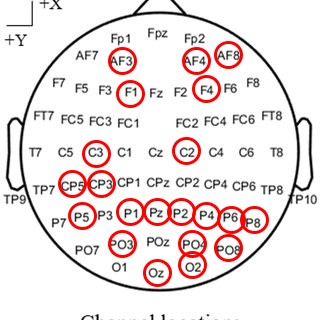

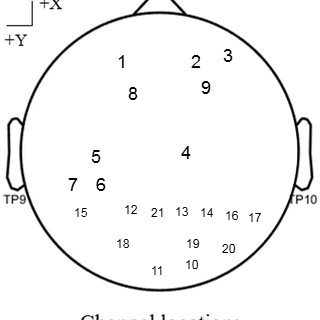

## Distribution Visualization
For identifying outliers

Histogram for the distribution of number of channels for each subject

Text(0, 0.5, 'Frequency')

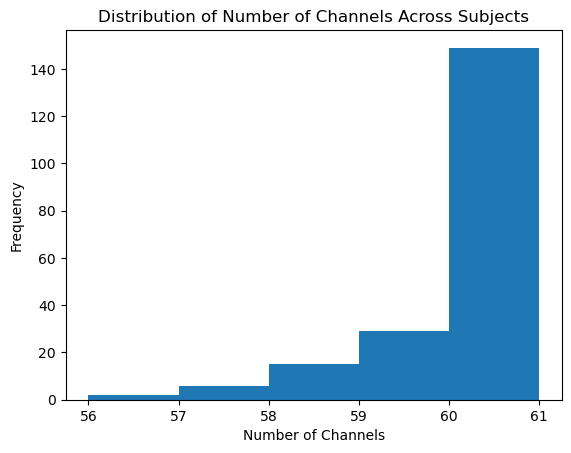

In [114]:
num_chan = []
for i in ID:
    subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
    raw = mne.io.read_raw_eeglab(subj_path, preload=False, verbose = 'ERROR')
    num_chan.append(len(raw.info['ch_names']))

plt.hist(num_chan, bins=5)
plt.title('Distribution of Number of Channels Across Subjects')
plt.xlabel('Number of Channels')
plt.ylabel('Frequency')

Histogram of the time length of the experiment per subject

Text(0, 0.5, 'Frequency')

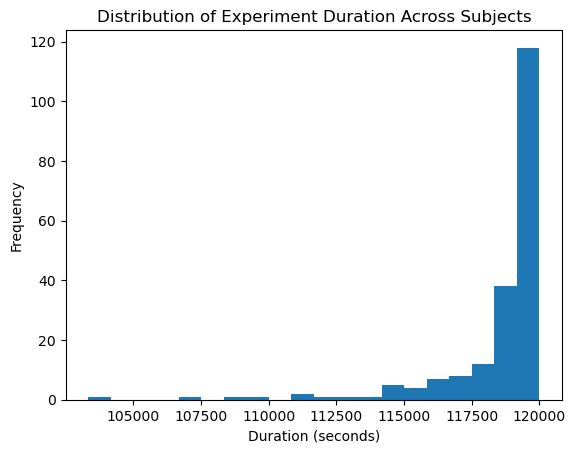

In [115]:
exp_time = []
for i in ID:
    subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
    raw = mne.io.read_raw_eeglab(subj_path, preload=False, verbose = 'ERROR')
    data = raw.get_data()
    exp_time.append(data.shape[1])

plt.hist(exp_time, bins=20)
plt.title('Distribution of Experiment Duration Across Subjects')
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')

Finding the outlier in the time length

In [ ]:
for i in range(len(ID)):
    if exp_time[i] < 90000:
        print(i)

167
168


In [110]:
print(f"{ID[167]}: {exp_time[167]}")
print(f"{ID[168]}: {exp_time[168]}")

sub-010276: 47624
sub-010277: 47815


## Preprocessing: Interpolating Missing Channels
1. Find all present channels
2. For each subject, compare the channels it has to the preexisting full channel list. Mark any missing as "bads"
3. Interpolate the bads

In [6]:
# Finding all present channels across all subjects
all_channels = set()
for i in ID:
    subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
    raw = mne.io.read_raw_eeglab(subj_path, preload=False, verbose = 'ERROR')
    all_channels.update(set(raw.info['ch_names']))
print(f'All channels across all subjects: {sorted(list(all_channels))}')
print(f'Number of unique channels across all subjects: {len(all_channels)}')

All channels across all subjects: ['AF3', 'AF4', 'AF7', 'AF8', 'AFz', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'CPz', 'Cz', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6', 'FT7', 'FT8', 'Fp1', 'Fp2', 'Fz', 'O1', 'O2', 'Oz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO10', 'PO3', 'PO4', 'PO7', 'PO8', 'PO9', 'POz', 'Pz', 'T7', 'T8', 'TP7', 'TP8']
Number of unique channels across all subjects: 61


In [ ]:
# mne.channels.get_builtin_montages()

['standard_1005',
 'standard_1020',
 'standard_alphabetic',
 'standard_postfixed',
 'standard_prefixed',
 'standard_primed',
 'biosemi16',
 'biosemi32',
 'biosemi64',
 'biosemi128',
 'biosemi160',
 'biosemi256',
 'easycap-M1',
 'easycap-M10',
 'easycap-M43',
 'EGI_256',
 'GSN-HydroCel-32',
 'GSN-HydroCel-64_1.0',
 'GSN-HydroCel-65_1.0',
 'GSN-HydroCel-128',
 'GSN-HydroCel-129',
 'GSN-HydroCel-256',
 'GSN-HydroCel-257',
 'mgh60',
 'mgh70',
 'artinis-octamon',
 'artinis-brite23',
 'brainproducts-RNP-BA-128']

In [7]:
montage = mne.channels.make_standard_montage('standard_1005') # Just picked the first one

# For each subject, compare the channels it has to the preexisting full channel list. Mark any missing as raw.info['bads']
def get_data(ID, main_dir, montage, all_channels):
    data = []
    for i in ID:
        subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
        raw = mne.io.read_raw_eeglab(subj_path, preload=True, verbose = 'ERROR')
        missing_channels = set(all_channels) - set(raw.info['ch_names'])
        # Dummy channels
        if missing_channels:
            dummy_data = np.zeros((len(missing_channels), raw.n_times))
            dummy_info = mne.create_info(ch_names=list(missing_channels), sfreq=raw.info['sfreq'], ch_types='eeg')
            dummy_raw = mne.io.RawArray(dummy_data, dummy_info, verbose='ERROR')
            raw.add_channels([dummy_raw], force_update_info=True)

        raw.info['bads'] = list(missing_channels)
        # Interpolate the bad channels
        raw.set_montage(montage, on_missing='ignore') 
        raw_interp = raw.interpolate_bads(verbose = 'ERROR') # default is spherical splines 
        # raw_interp = raw.interpolate_bads(reset_bads=False, verbose='ERROR')
        # raw_interp.plot(n_channels = 61) 
        subj_2d = raw_interp.get_data()
        data.append(subj_2d)

    # Slice to shortest time
    time_length = min([subj.shape[1] for subj in data])
    for i in range(len(data)):
        data[i] = data[i][:, :time_length]

    # Stack to 3D array
    data = np.stack(data, axis=0) 

    print(data.shape)
    return data

In [8]:
data = get_data(ID, main_dir, montage, all_channels)

(201, 61, 103348)


## *Don't Use*
Was used for common channels, but now have interpolation

In [ ]:
# def get_data(ID, main_dir):
    data = [] # Initialize an empty list (lists use .append(), not indices!)

    # Read data per subject
    for i in (ID):
        subj_path = main_dir + f'\\{i}\\EC\\{i}_EC.set'
        raw = mne.io.read_raw_eeglab(subj_path, preload=True, verbose='ERROR') 
        raw.pick(common_channels) 
        subj_2d = raw.get_data() 
        data.append(subj_2d) 

    # Slice to shortest time
    time_length = min([subj.shape[1] for subj in data])
    for i in range(len(data)):
        data[i] = data[i][:, :time_length]

    # Stack to 3D array
    data = np.stack(data, axis=0) 

    print(data.shape)
    return data

data = get_data(ID, main_dir)

NameError: name 'main_dir' is not defined

---
# dDTF Calculation

The following dDTF calculation code is adapted from ChiShengChen on Github, cal_ddtf.py. Link: https://github.com/ChiShengChen/dDTF 

In [9]:
# From ChiShengChen on Github, cal_ddtf.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import ttest_rel
from numpy.linalg import inv, eigvals

# Parameters
n_subjects = data.shape[0]
n_channels = data.shape[1]
n_timepoints = data.shape[2]

fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

In [10]:
# Functions, for non-singular matrices

def compute_mvar_coefficients(X, order=5):
    # Estimate MVAR coefficients using least squares
    T = X.shape[-1]
    Y = X[:, order:]
    Z = np.concatenate([X[:, order - k - 1:T - k - 1] for k in range(order)], axis=0)
    # print(f'MAX Z: {np.max(Z)}')
    A = Y @ Z.T @ inv(Z @ Z.T) # for nonsingular matrices
    # print(f'MAX A: {np.max(A)}')
    return A.reshape(n_channels, order, n_channels)

def compute_dtf(A, freqs, fs):
    order = A.shape[1]
    H = np.zeros((n_channels, n_channels, len(freqs)), dtype=np.complex_)
    I = np.eye(n_channels)
    for f_idx, f in enumerate(freqs):
        exp_term = sum(A[:, k, :] * np.exp(-2j * np.pi * f * (k + 1) / fs) for k in range(order))
        H[:, :, f_idx] = inv(I - exp_term)
    dtf = np.abs(H) ** 2
    dtf_norm = dtf / dtf.sum(axis=1, keepdims=True)
    return dtf_norm


In [12]:
# Compute dDTF for each dataset
dtf1_all = []

for s in range(n_subjects):
    A1 = compute_mvar_coefficients(data[s], order=5)
    # print(max(A1.flatten()))
    dtf1 = compute_dtf(A1, freqs, fs)
    dtf1_all.append(dtf1.mean(axis=-1))  # Average over freq

dtf1_all = np.stack(dtf1_all)


In [70]:
# For All Subjects
# # Compute connectivity strength and directionality
conn_strength1 = dtf1_all.mean(axis=0) # Average over subjects
directionality1 = (conn_strength1 - conn_strength1.T) / (conn_strength1 + conn_strength1.T + 1e-8) 
# Positive directionality - source to target, negative - target to source

# # For Individual Subjects
# conn_strength1 = dtf1_all[175]
# directionality1 = (conn_strength1 - conn_strength1.T) / (conn_strength1 + conn_strength1.T + 1e-8)


In [ ]:
# Comparison stats

# Paired t-test
p_values = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        _, p = ttest_rel(dtf1_all[:, i, j], dtf2_all[:, i, j])
        p_values[i, j] = p

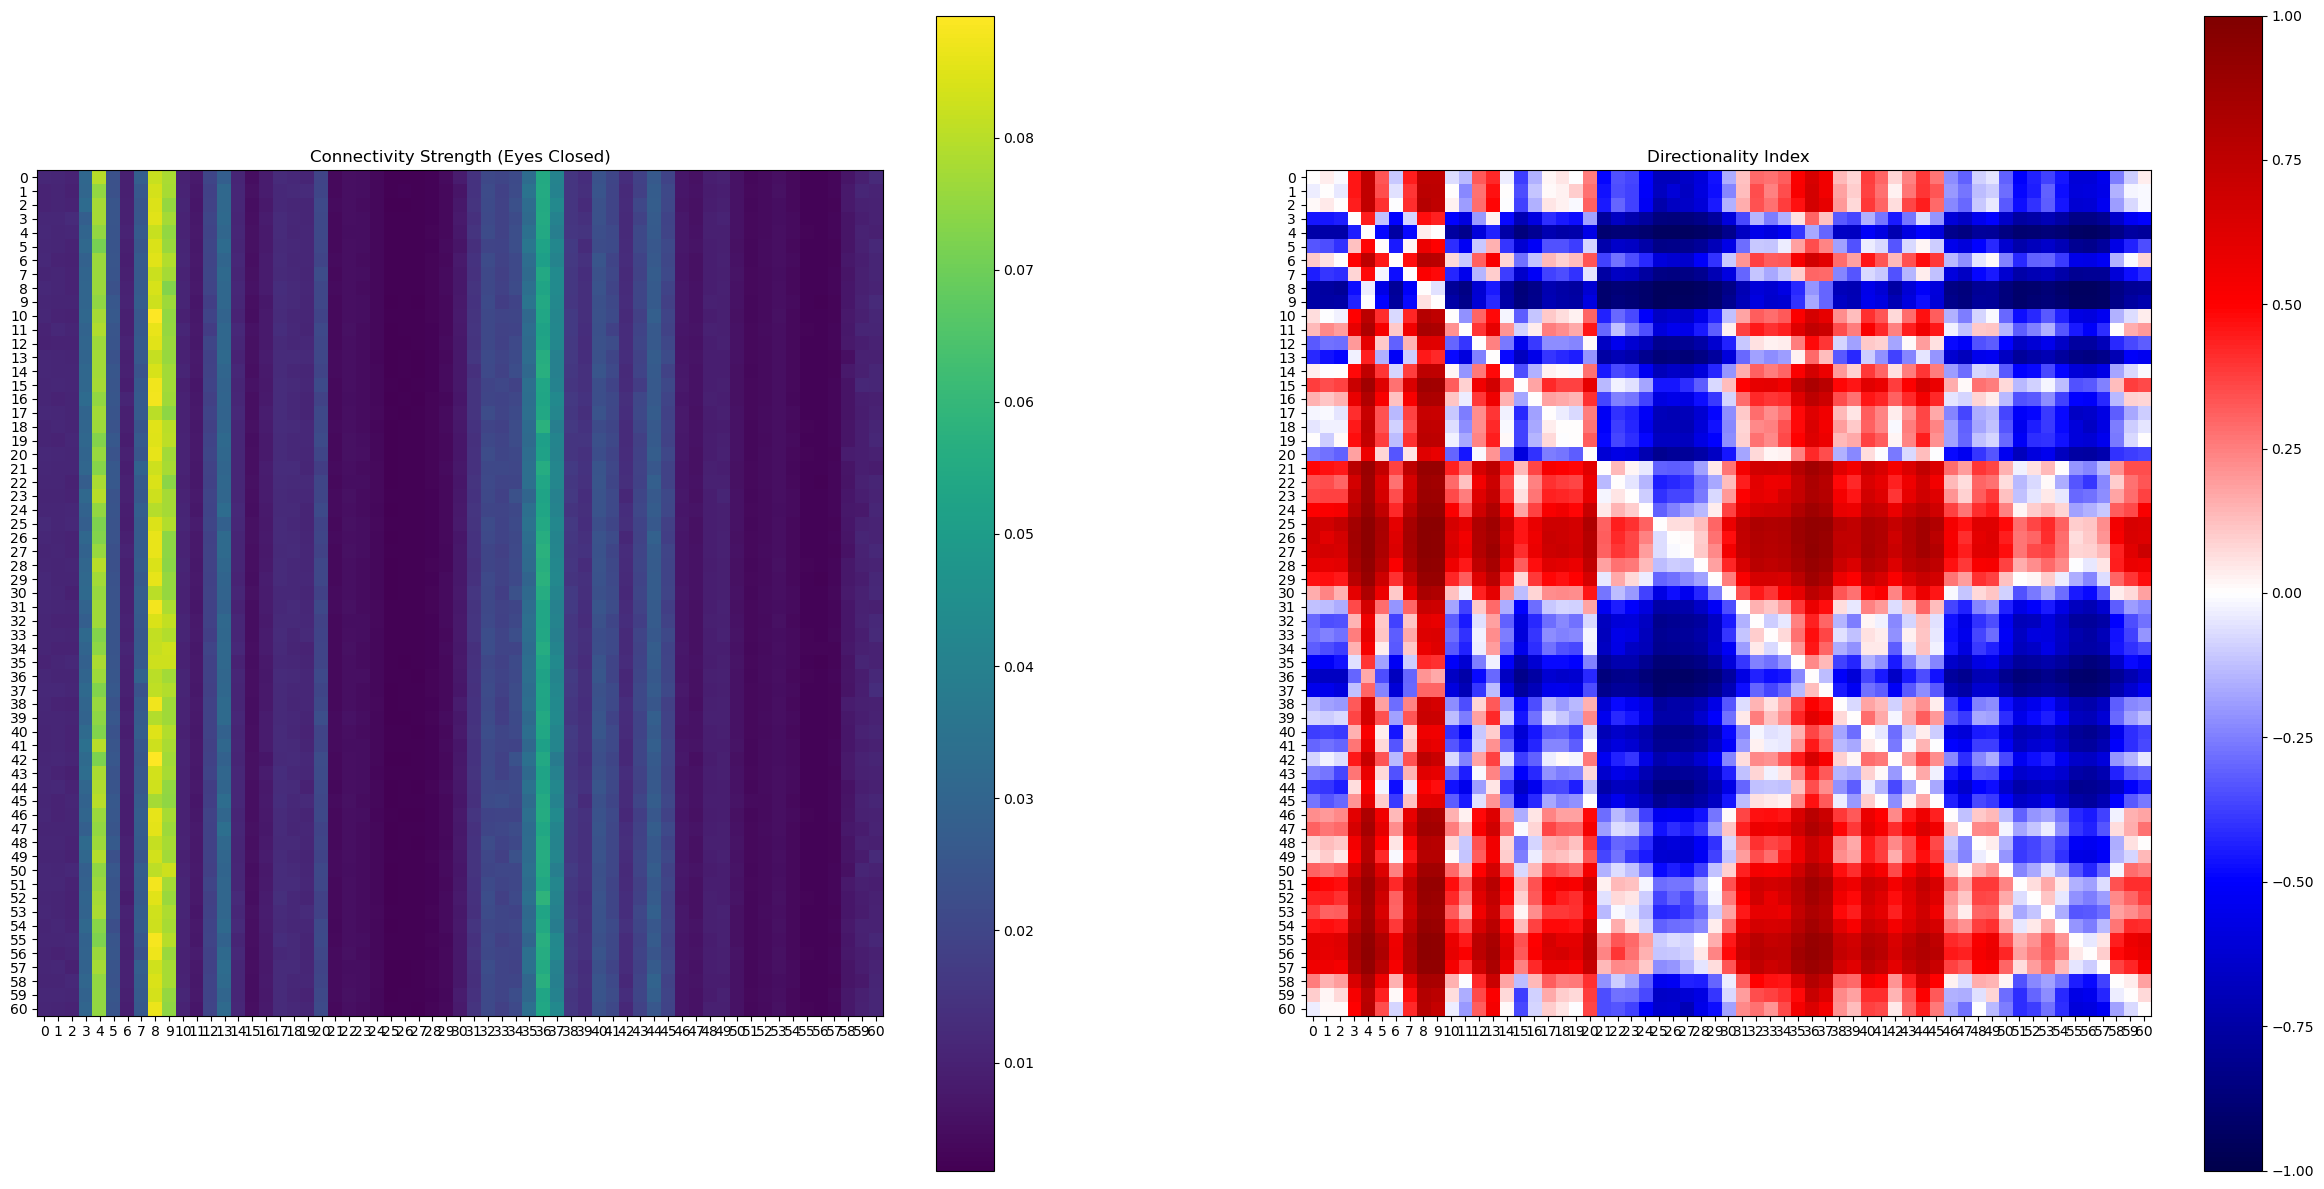

In [71]:
# Visualize
fig, axs = plt.subplots(1, 2, figsize=(30, 15))

im1 = axs[0].imshow(conn_strength1, cmap='viridis')
axs[0].set_title('Connectivity Strength (Eyes Closed)')
plt.colorbar(im1, ax=axs[0])
axs[0].set_xticks(range(n_channels))
axs[0].set_yticks(range(n_channels))

im2 = axs[1].imshow(directionality1, cmap='seismic', vmin=-1, vmax=1)
axs[1].set_title('Directionality Index')
plt.colorbar(im2, ax=axs[1])
axs[1].set_xticks(range(n_channels))
axs[1].set_yticks(range(n_channels))

# im3 = axs[2].imshow(p_values, cmap='hot_r')
# axs[2].set_title('P-values (Condition1 vs Condition2)')
# plt.colorbar(im3, ax=axs[2])

# plt.tight_layout()
plt.show()

Curious to see that channel 12 seems to have strong connectivity with all other channels? It also seems to be highly positive in directionality (which I think means it's the source?) Checking to see what it is
(Note: index so it's one off)

In [ ]:
print(common_channels[12])

P2


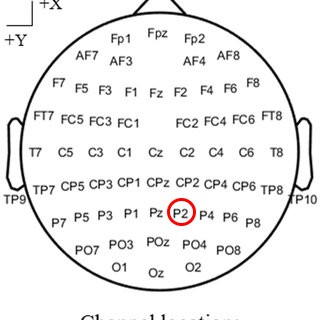

In [59]:
# Visualize for every subject, and save as images
# For Individual Subjects
def visualize(n_subjects, dtf, n_channels, newdir, ID):
    os.makedirs(newdir, exist_ok=True)
    os.chdir(newdir)
    n_subjects = dtf.shape[0]
    for i in range(n_subjects):
        conn_strength1 = dtf[i]
        directionality1 = (conn_strength1 - conn_strength1.T) / (conn_strength1 + conn_strength1.T + 1e-8)
        # Visualize
        fig, axs = plt.subplots(1, 2, figsize=(30, 15))

        im1 = axs[0].imshow(conn_strength1, cmap='viridis')
        axs[0].set_title('Connectivity Strength (Eyes Closed)')
        plt.colorbar(im1, ax=axs[0])
        axs[0].set_xticks(range(n_channels))
        axs[0].set_yticks(range(n_channels))

        im2 = axs[1].imshow(directionality1, cmap='seismic', vmin=-1, vmax=1)
        axs[1].set_title('Directionality Index')
        plt.colorbar(im2, ax=axs[1])
        axs[1].set_xticks(range(n_channels))
        axs[1].set_yticks(range(n_channels))
        plt.suptitle(f'Subject {ID[i]}')
        # Save image
        plt.savefig(f'{ID[i]}_connectivity.png')
        plt.close()
    # One average graph
    conn_strength1 = dtf.mean(axis=0) # Average over subjects
    directionality1 = (conn_strength1 - conn_strength1.T) / (conn_strength1 + conn_strength1.T + 1e-8) 
    fig, axs = plt.subplots(1, 2, figsize=(30, 15))
    im1 = axs[0].imshow(conn_strength1, cmap='viridis')
    axs[0].set_title('Average Connectivity Strength (Eyes Closed)')
    plt.colorbar(im1, ax=axs[0])
    axs[0].set_xticks(range(n_channels))
    axs[0].set_yticks(range(n_channels))
    im2 = axs[1].imshow(directionality1, cmap='seismic', vmin=-1, vmax=1)
    axs[1].set_title('Average Directionality Index')
    plt.colorbar(im2, ax=axs[1])
    axs[1].set_xticks(range(n_channels))
    axs[1].set_yticks(range(n_channels))
    plt.suptitle('Average Connectivity Patterns')
    # Save image
    plt.savefig('average_connectivity.png')
    plt.close()

# visualize(n_subjects, dtf1_all, n_channels)

# Grouping by Education Levels

Education levels stated in metadata

In [13]:
# import metadata csv, group ID by education
import pandas as pd
metadata = pd.read_csv(r'C:/Users/Einez (School)/Desktop/Chang_EEG_LEMON/Education_META_File_IDs_Age_Gender_Education_Drug_Smoke_SKID_LEMON.csv')
gym = metadata[metadata["Education"] == "Gymnasium"]
gym_IDs = gym['ID'].tolist()
real = metadata[metadata["Education"] == "Realschule"]
real_IDs = real['ID'].tolist()
haupt = metadata[metadata["Education"] == "Hauptschule"]
haupt_IDs = haupt['ID'].tolist()

print(f'Gymnasium IDs: {gym_IDs}')
print(f'Realschule IDs: {real_IDs}')
print(f'Hauptschule IDs: {haupt_IDs}')

Gymnasium IDs: ['sub-010039', 'sub-010075', 'sub-010226', 'sub-010229', 'sub-010017', 'sub-010015', 'sub-010100', 'sub-010003', 'sub-010022', 'sub-010021', 'sub-010023', 'sub-010104', 'sub-010010', 'sub-010016', 'sub-010019', 'sub-010024', 'sub-010169', 'sub-010026', 'sub-010027', 'sub-010134', 'sub-010028', 'sub-010029', 'sub-010030', 'sub-010150', 'sub-010032', 'sub-010031', 'sub-010321', 'sub-010033', 'sub-010020', 'sub-010110', 'sub-010183', 'sub-010035', 'sub-010197', 'sub-010202', 'sub-010034', 'sub-010199', 'sub-010040', 'sub-010012', 'sub-010043', 'sub-010046', 'sub-010059', 'sub-010236', 'sub-010056', 'sub-010062', 'sub-010063', 'sub-010060', 'sub-010042', 'sub-010238', 'sub-010207', 'sub-010069', 'sub-010073', 'sub-010076', 'sub-010065', 'sub-010077', 'sub-010061', 'sub-010074', 'sub-010078', 'sub-010052', 'sub-010071', 'sub-010080', 'sub-010067', 'sub-010064', 'sub-010072', 'sub-010079', 'sub-010240', 'sub-010083', 'sub-010084', 'sub-010053', 'sub-010237', 'sub-010085', 'sub

In [16]:
# Not every subject that is in the metadata is in the EEG data, so we need to filter out the IDs that are not in the EEG data
gym_IDs = [id for id in gym_IDs if id in ID]
real_IDs = [id for id in real_IDs if id in ID]
haupt_IDs = [id for id in haupt_IDs if id in ID]

In [17]:
gym_data = get_data(gym_IDs, main_dir, montage, all_channels)
real_data = get_data(real_IDs, main_dir, montage, all_channels) 
haupt_data = get_data(haupt_IDs, main_dir, montage, all_channels)


(158, 61, 103348)
(37, 61, 111045)
(4, 61, 117382)


In [18]:
# Compute dDTF for gym dataset
n_channels = gym_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

gym_dtf_all = []
for s in range(gym_data.shape[0]):
    A1 = compute_mvar_coefficients(gym_data[s], order=5)
    # print(max(A1.flatten()))
    gym_dtf = compute_dtf(A1, freqs, fs)
    gym_dtf_all.append(gym_dtf.mean(axis=-1))  # Average over freq

gym_dtf_all = np.stack(gym_dtf_all)

In [19]:
# Compute dDTF for realschule dataset
n_channels = real_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

real_dtf_all = []
for s in range(real_data.shape[0]):
    A1 = compute_mvar_coefficients(real_data[s], order=5)
    # print(max(A1.flatten()))
    real_dtf = compute_dtf(A1, freqs, fs)
    real_dtf_all.append(real_dtf.mean(axis=-1))  # Average over freq

real_dtf_all = np.stack(real_dtf_all)

In [20]:
# Compute dDTF for haupt dataset
n_channels = haupt_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

haupt_dtf_all = []
for s in range(haupt_data.shape[0]):
    A1 = compute_mvar_coefficients(haupt_data[s], order=5)
    # print(max(A1.flatten()))
    haupt_dtf = compute_dtf(A1, freqs, fs)
    haupt_dtf_all.append(haupt_dtf.mean(axis=-1))  # Average over freq

haupt_dtf_all = np.stack(haupt_dtf_all)

In [60]:
graph_dir = r'C:/Users/Einez (School)/Desktop/Chang_EEG_LEMON/conn_graphs/Education'
visualize(gym_data.shape[0], gym_dtf_all, n_channels, newdir = graph_dir + '/gymnasium', ID = gym_IDs)
visualize(real_data.shape[0], real_dtf_all, n_channels, newdir = graph_dir + '/realschule', ID = real_IDs)
visualize(haupt_data.shape[0], haupt_dtf_all, n_channels, newdir = graph_dir + '/hauptschule', ID = haupt_IDs)

In [80]:
# ANOVA test between all groups
from scipy.stats import f_oneway
print(f'Number of total comparisons: {n_channels * n_channels}')

p_values_anova = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        f_stat, p = f_oneway(gym_dtf_all[:, i, j], real_dtf_all[:, i, j], haupt_dtf_all[:, i, j])
        p_values_anova[i, j] = p
# show where p < 0.05
stat_sig_dtf = p_values_anova < 0.01
print("All Three Groups ANOVA Results:")
print(f'Number of significant differences (p < 0.01) in ANOVA: {np.sum(stat_sig_dtf)}')
print(f'Max significant p-value: {np.max(p_values_anova[stat_sig_dtf]):.4f}, min significant p-value: {np.min(p_values_anova[stat_sig_dtf]):.4f}')
# print(f'Connections with significant differences (p < 0.01) in ANOVA: {np.argwhere(stat_sig_dtf)}')
print("---")

# ANOVA between groups
# gym vs. real
p_values_gym_real = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        f_stat, p = f_oneway(gym_dtf_all[:, i, j], real_dtf_all[:, i, j])
        p_values_gym_real[i, j] = p
stat_sig_dtf = p_values_gym_real < 0.01
print("Gym vs. Real ANOVA Results:")
print(f'Number of significant differences (p < 0.01) in ANOVA: {np.sum(stat_sig_dtf)}')
print(f'Max significant p-value: {np.max(p_values_gym_real[stat_sig_dtf]):.4f}, min significant p-value: {np.min(p_values_gym_real[stat_sig_dtf]):.4f}')
# print(f'Connections with significant differences (p < 0.01) in ANOVA: {np.argwhere(stat_sig_dtf)}')
print("---")


# gym vs. haupt
p_values_gym_haupt = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        f_stat, p = f_oneway(gym_dtf_all[:, i, j], haupt_dtf_all[:, i, j])
        p_values_gym_haupt[i, j] = p
stat_sig_dtf = p_values_gym_haupt < 0.01
print("Gym vs. Haupt ANOVA Results:")
print(f'Number of significant differences (p < 0.01) in ANOVA: {np.sum(stat_sig_dtf)}')
print(f'Max significant p-value: {np.max(p_values_gym_haupt[stat_sig_dtf]):.4f}, min significant p-value: {np.min(p_values_gym_haupt[stat_sig_dtf]):.4f}')
# print(f'Connections with significant differences (p < 0.01) in ANOVA: {np.argwhere(stat_sig_dtf)}')
print("---")

# real vs. haupt
p_values_real_haupt = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        f_stat, p = f_oneway(real_dtf_all[:, i, j], haupt_dtf_all[:, i, j])
        p_values_real_haupt[i, j] = p
stat_sig_dtf = p_values_real_haupt < 0.01
print("Real vs. Haupt ANOVA Results:")
print(f'Number of significant differences (p < 0.01) in ANOVA: {np.sum(stat_sig_dtf)}')
print(f'Max significant p-value: {np.max(p_values_real_haupt[stat_sig_dtf]):.4f}, min significant p-value: {np.min(p_values_real_haupt[stat_sig_dtf]):.4f}')
# print(f'Connections with significant differences (p < 0.05) in ANOVA: {np.argwhere(stat_sig_dtf)}')

Number of total comparisons: 3721
All Three Groups ANOVA Results:
Number of significant differences (p < 0.01) in ANOVA: 34
Max significant p-value: 0.0099, min significant p-value: 0.0007
---
Gym vs. Real ANOVA Results:
Number of significant differences (p < 0.01) in ANOVA: 56
Max significant p-value: 0.0099, min significant p-value: 0.0003
---
Gym vs. Haupt ANOVA Results:
Number of significant differences (p < 0.01) in ANOVA: 9
Max significant p-value: 0.0098, min significant p-value: 0.0003
---
Real vs. Haupt ANOVA Results:
Number of significant differences (p < 0.01) in ANOVA: 12
Max significant p-value: 0.0076, min significant p-value: 0.0003


Stat results show the following conclusions:
- there are statistically significant differences in connections between groups
- largest number of differences between gymnasium and realschule
- least number of differences between gymnasium and hauptschule

### Network-based statistics

In [21]:
import bct

In [24]:
# Reshape so that it's channel x channel x subject
gym_conn_nbs = np.transpose(gym_dtf_all, (1, 2, 0))
real_conn_nbs = np.transpose(real_dtf_all, (1, 2, 0))
haupt_conn_nbs = np.transpose(haupt_dtf_all, (1, 2, 0))

print(gym_conn_nbs.shape)
print(real_conn_nbs.shape)
print(haupt_conn_nbs.shape)

(61, 61, 158)
(61, 61, 37)
(61, 61, 4)


In [44]:
print("Gym vs. Real NBS Results:")
gym_real_nbs_pval, gym_real_nbs_adj, gym_real_nbs_null= bct.nbs_bct(gym_conn_nbs, real_conn_nbs, 1)
real_gym_nbs_pval, real_gym_nbs_adj, real_gym_nbs_null = bct.nbs_bct(real_conn_nbs, gym_conn_nbs, 1)

print("Real vs. Haupt NBS Results:")
real_haupt_nbs_pval, real_haupt_nbs_adj, real_haupt_nbs_null = bct.nbs_bct(real_conn_nbs, haupt_conn_nbs, 1)
haupt_real_nbs_pval, haupt_real_nbs_adj, haupt_real_nbs_null = bct.nbs_bct(haupt_conn_nbs, real_conn_nbs, 1)

print("Gym vs. Haupt NBS Results:")
gym_haupt_nbs_pval, gym_haupt_nbs_adj, gym_haupt_nbs_null = bct.nbs_bct(gym_conn_nbs, haupt_conn_nbs, 1)
haupt_gym_nbs_pval, haupt_gym_nbs_adj, haupt_gym_nbs_null = bct.nbs_bct(haupt_conn_nbs, gym_conn_nbs, 1)

Gym vs. Real NBS Results:
max component size is 744
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 1.000
permutation 100 of 1000.  p-value so far is 0.139
permutation 200 of 1000.  p-value so far is 0.139
permutation 300 of 1000.  p-value so far is 0.146
permutation 400 of 1000.  p-value so far is 0.145
permutation 500 of 1000.  p-value so far is 0.134
permutation 600 of 1000.  p-value so far is 0.133
permutation 700 of 1000.  p-value so far is 0.120
permutation 800 of 1000.  p-value so far is 0.112
permutation 900 of 1000.  p-value so far is 0.108
permutation 999 of 1000.  p-value so far is 0.108
max component size is 744
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 0.000
permutation 100 of 1000.  p-value so far is 0.050
permutation 200 of 1000.  p-value so far is 0.060
permutation 300 of 1000.  p-value so far is 0.083
permutation 400 of 1000.  p-value so far is 0.082
permutation 500 of 100

---
# Grouped by Age

Age groups stated in metadata

In [28]:
# import metadata csv, group ID by education
import pandas as pd
metadata = pd.read_csv(r'C:/Users/Einez (School)/Desktop/Chang_EEG_LEMON/Age_META_File_IDs_Age_Gender_Education_Drug_Smoke_SKID_LEMON.csv')
# Extract all age groups
age_groups = metadata['Age'].unique()
print(f'Age groups in metadata: {age_groups}')
age_20_25 = metadata[metadata["Age"] == age_groups[0]]
age_20_25_IDs = age_20_25['ID'].tolist()
age_25_30 = metadata[metadata["Age"] == age_groups[1]]
age_25_30_IDs = age_25_30['ID'].tolist()
age_60_65 = metadata[metadata["Age"] == age_groups[2]]
age_60_65_IDs = age_60_65['ID'].tolist()
age_30_35 = metadata[metadata["Age"] == age_groups[3]]
age_30_35_IDs = age_30_35['ID'].tolist()
age_70_75 = metadata[metadata["Age"] == age_groups[4]]
age_70_75_IDs = age_70_75['ID'].tolist()
age_65_70 = metadata[metadata["Age"] == age_groups[5]]
age_65_70_IDs = age_65_70['ID'].tolist()
age_75_80 = metadata[metadata["Age"] == age_groups[6]]
age_75_80_IDs = age_75_80['ID'].tolist()
age_55_60 = metadata[metadata["Age"] == age_groups[7]]
age_55_60_IDs = age_55_60['ID'].tolist()
age_35_40 = metadata[metadata["Age"] == age_groups[8]]
age_35_40_IDs = age_35_40['ID'].tolist()

print(f'20-25 IDs: {age_20_25_IDs}')
print(f'25-30 IDs: {age_25_30_IDs}')
print(f'30-35 IDs: {age_30_35_IDs}')
print(f'35-40 IDs: {age_35_40_IDs}')
print(f'55-60 IDs: {age_55_60_IDs}')
print(f'60-65 IDs: {age_60_65_IDs}')
print(f'65-70 IDs: {age_65_70_IDs}')
print(f'70-75 IDs: {age_70_75_IDs}')
print(f'75-80 IDs: {age_75_80_IDs}')

Age groups in metadata: ['20-25' '25-30' '30-35' '35-40' '55-60' '60-65' '65-70' '70-75' '75-80']
20-25 IDs: ['sub-010017', 'sub-010015', 'sub-010003', 'sub-010022', 'sub-010019', 'sub-010024', 'sub-010169', 'sub-010027', 'sub-010134', 'sub-010030', 'sub-010150', 'sub-010032', 'sub-010031', 'sub-010321', 'sub-010033', 'sub-010020', 'sub-010183', 'sub-010197', 'sub-010202', 'sub-010040', 'sub-010056', 'sub-010063', 'sub-010070', 'sub-010238', 'sub-010207', 'sub-010069', 'sub-010073', 'sub-010075', 'sub-010065', 'sub-010077', 'sub-010078', 'sub-010067', 'sub-010064', 'sub-010083', 'sub-010084', 'sub-010053', 'sub-010241', 'sub-010252', 'sub-010126', 'sub-010262', 'sub-010141', 'sub-010265', 'sub-010260', 'sub-010263', 'sub-010271', 'sub-010269', 'sub-010165', 'sub-010162', 'sub-010270', 'sub-010155', 'sub-010164', 'sub-010261', 'sub-010266', 'sub-010166', 'sub-010157', 'sub-010293', 'sub-010292', 'sub-010195', 'sub-010294', 'sub-010298', 'sub-010200', 'sub-010299', 'sub-010300', 'sub-010

In [29]:
# Not every subject that is in the metadata is in the EEG data, so we need to filter out the IDs that are not in the EEG data
age_20_25_IDs = [id for id in age_20_25_IDs if id in ID]
age_25_30_IDs = [id for id in age_25_30_IDs if id in ID]
age_30_35_IDs = [id for id in age_30_35_IDs if id in ID]
age_35_40_IDs = [id for id in age_35_40_IDs if id in ID]
age_55_60_IDs = [id for id in age_55_60_IDs if id in ID]
age_60_65_IDs = [id for id in age_60_65_IDs if id in ID]
age_65_70_IDs = [id for id in age_65_70_IDs if id in ID]
age_70_75_IDs = [id for id in age_70_75_IDs if id in ID]
age_75_80_IDs = [id for id in age_75_80_IDs if id in ID]

print(f'20-25 IDs: {age_20_25_IDs}')
print(f'25-30 IDs: {age_25_30_IDs}')
print(f'30-35 IDs: {age_30_35_IDs}')
print(f'35-40 IDs: {age_35_40_IDs}')
print(f'55-60 IDs: {age_55_60_IDs}')
print(f'60-65 IDs: {age_60_65_IDs}')
print(f'65-70 IDs: {age_65_70_IDs}')
print(f'70-75 IDs: {age_70_75_IDs}')
print(f'75-80 IDs: {age_75_80_IDs}')

20-25 IDs: ['sub-010017', 'sub-010003', 'sub-010022', 'sub-010019', 'sub-010024', 'sub-010027', 'sub-010134', 'sub-010030', 'sub-010150', 'sub-010032', 'sub-010031', 'sub-010321', 'sub-010033', 'sub-010020', 'sub-010183', 'sub-010197', 'sub-010202', 'sub-010040', 'sub-010056', 'sub-010063', 'sub-010070', 'sub-010238', 'sub-010207', 'sub-010069', 'sub-010073', 'sub-010075', 'sub-010065', 'sub-010067', 'sub-010064', 'sub-010083', 'sub-010084', 'sub-010053', 'sub-010241', 'sub-010252', 'sub-010126', 'sub-010262', 'sub-010141', 'sub-010265', 'sub-010260', 'sub-010263', 'sub-010271', 'sub-010269', 'sub-010165', 'sub-010162', 'sub-010270', 'sub-010155', 'sub-010164', 'sub-010261', 'sub-010266', 'sub-010166', 'sub-010157', 'sub-010292', 'sub-010195', 'sub-010294', 'sub-010298', 'sub-010200', 'sub-010299', 'sub-010300', 'sub-010303', 'sub-010319', 'sub-010305', 'sub-010304', 'sub-010310', 'sub-010311', 'sub-010228', 'sub-010315', 'sub-010317', 'sub-010227', 'sub-010230', 'sub-010231', 'sub-010

In [30]:
age_20_25_data = get_data(age_20_25_IDs, main_dir, montage, all_channels)
age_25_30_data = get_data(age_25_30_IDs, main_dir, montage, all_channels)
age_30_35_data = get_data(age_30_35_IDs, main_dir, montage, all_channels)
age_35_40_data = get_data(age_35_40_IDs, main_dir, montage, all_channels)
age_55_60_data = get_data(age_55_60_IDs, main_dir, montage, all_channels)
age_60_65_data = get_data(age_60_65_IDs, main_dir, montage, all_channels)
age_65_70_data = get_data(age_65_70_IDs, main_dir, montage, all_channels)
age_70_75_data = get_data(age_70_75_IDs, main_dir, montage, all_channels)
age_75_80_data = get_data(age_75_80_IDs, main_dir, montage, all_channels)


(71, 61, 107238)
(54, 61, 103348)
(1, 61, 118914)
(3, 61, 118486)
(18, 61, 112815)
(12, 61, 117878)
(16, 61, 109711)
(3, 61, 119371)
(23, 61, 111045)


In [31]:
# Compute dDTF for gym dataset
n_channels = age_20_25_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_20_25_dtf_all = []
for s in range(age_20_25_data.shape[0]):
    A1 = compute_mvar_coefficients(age_20_25_data[s], order=5)
    # print(max(A1.flatten()))
    age_20_25_dtf = compute_dtf(A1, freqs, fs)
    age_20_25_dtf_all.append(age_20_25_dtf.mean(axis=-1))  # Average over freq

age_20_25_dtf_all = np.stack(age_20_25_dtf_all)

In [32]:
# Compute dDTF for gym dataset
n_channels = age_25_30_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_25_30_dtf_all = []
for s in range(age_25_30_data.shape[0]):
    A1 = compute_mvar_coefficients(age_25_30_data[s], order=5)
    # print(max(A1.flatten()))
    age_25_30_dtf = compute_dtf(A1, freqs, fs)
    age_25_30_dtf_all.append(age_25_30_dtf.mean(axis=-1))  # Average over freq

age_25_30_dtf_all = np.stack(age_25_30_dtf_all)

In [33]:
# Compute dDTF for gym dataset
n_channels = age_30_35_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_30_35_dtf_all = []
for s in range(age_30_35_data.shape[0]):
    A1 = compute_mvar_coefficients(age_30_35_data[s], order=5)
    # print(max(A1.flatten()))
    age_30_35_dtf = compute_dtf(A1, freqs, fs)
    age_30_35_dtf_all.append(age_30_35_dtf.mean(axis=-1))  # Average over freq

age_30_35_dtf_all = np.stack(age_30_35_dtf_all)

In [34]:
# Compute dDTF for gym dataset
n_channels = age_35_40_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_35_40_dtf_all = []
for s in range(age_35_40_data.shape[0]):
    A1 = compute_mvar_coefficients(age_35_40_data[s], order=5)
    # print(max(A1.flatten()))
    age_35_40_dtf = compute_dtf(A1, freqs, fs)
    age_35_40_dtf_all.append(age_35_40_dtf.mean(axis=-1))  # Average over freq

age_35_40_dtf_all = np.stack(age_35_40_dtf_all)

In [35]:
# Compute dDTF for gym dataset
n_channels = age_55_60_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_55_60_dtf_all = []
for s in range(age_55_60_data.shape[0]):
    A1 = compute_mvar_coefficients(age_55_60_data[s], order=5)
    # print(max(A1.flatten()))
    age_55_60_dtf = compute_dtf(A1, freqs, fs)
    age_55_60_dtf_all.append(age_55_60_dtf.mean(axis=-1))  # Average over freq

age_55_60_dtf_all = np.stack(age_55_60_dtf_all)

In [36]:
# Compute dDTF for gym dataset
n_channels = age_60_65_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_60_65_dtf_all = []
for s in range(age_60_65_data.shape[0]):
    A1 = compute_mvar_coefficients(age_60_65_data[s], order=5)
    # print(max(A1.flatten()))
    age_60_65_dtf = compute_dtf(A1, freqs, fs)
    age_60_65_dtf_all.append(age_60_65_dtf.mean(axis=-1))  # Average over freq

age_60_65_dtf_all = np.stack(age_60_65_dtf_all)

In [37]:
# Compute dDTF for gym dataset
n_channels = age_65_70_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_65_70_dtf_all = []
for s in range(age_65_70_data.shape[0]):
    A1 = compute_mvar_coefficients(age_65_70_data[s], order=5)
    # print(max(A1.flatten()))
    age_65_70_dtf = compute_dtf(A1, freqs, fs)
    age_65_70_dtf_all.append(age_65_70_dtf.mean(axis=-1))  # Average over freq

age_65_70_dtf_all = np.stack(age_65_70_dtf_all)

In [38]:
# Compute dDTF for gym dataset
n_channels = age_70_75_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_70_75_dtf_all = []
for s in range(age_70_75_data.shape[0]):
    A1 = compute_mvar_coefficients(age_70_75_data[s], order=5)
    # print(max(A1.flatten()))
    age_70_75_dtf = compute_dtf(A1, freqs, fs)
    age_70_75_dtf_all.append(age_70_75_dtf.mean(axis=-1))  # Average over freq

age_70_75_dtf_all = np.stack(age_70_75_dtf_all)

In [39]:
# Compute dDTF for gym dataset
n_channels = age_75_80_data.shape[1]
fs = 100  # Hz
freqs = np.linspace(8, 12, 20)  # Alpha band

age_75_80_dtf_all = []
for s in range(age_75_80_data.shape[0]):
    A1 = compute_mvar_coefficients(age_75_80_data[s], order=5)
    # print(max(A1.flatten()))
    age_75_80_dtf = compute_dtf(A1, freqs, fs)
    age_75_80_dtf_all.append(age_75_80_dtf.mean(axis=-1))  # Average over freq

age_75_80_dtf_all = np.stack(age_75_80_dtf_all)

In [76]:
graph_dir = r'C:/Users/Einez (School)/Desktop/Chang_EEG_LEMON/conn_graphs/Age'
visualize(age_20_25_data.shape[0], age_20_25_dtf_all, n_channels, newdir = graph_dir + '/20-25', ID = age_20_25_IDs)
visualize(age_25_30_data.shape[0], age_25_30_dtf_all, n_channels, newdir = graph_dir + '/25-30', ID = age_25_30_IDs)
visualize(age_30_35_data.shape[0], age_30_35_dtf_all, n_channels, newdir = graph_dir + '/30-35', ID = age_30_35_IDs)
visualize(age_35_40_data.shape[0], age_35_40_dtf_all, n_channels, newdir = graph_dir + '/35-40', ID = age_35_40_IDs)
visualize(age_55_60_data.shape[0], age_55_60_dtf_all, n_channels, newdir = graph_dir + '/55-60', ID = age_55_60_IDs)
visualize(age_60_65_data.shape[0], age_60_65_dtf_all, n_channels, newdir = graph_dir + '/60-65', ID = age_60_65_IDs)
visualize(age_65_70_data.shape[0], age_65_70_dtf_all, n_channels, newdir = graph_dir + '/65-70', ID = age_65_70_IDs)
visualize(age_70_75_data.shape[0], age_70_75_dtf_all, n_channels, newdir = graph_dir + '/70-75', ID = age_70_75_IDs)
visualize(age_75_80_data.shape[0], age_75_80_dtf_all, n_channels, newdir = graph_dir + '/75-80', ID = age_75_80_IDs) 

In [81]:
# ANOVA test between all groups
from scipy.stats import f_oneway
print(f'Number of total comparisons: {n_channels * n_channels}')
print()
p_values_anova = np.zeros((n_channels, n_channels))
for i in range(n_channels):
    for j in range(n_channels):
        f_stat, p = f_oneway(age_20_25_dtf_all[:, i, j], age_25_30_dtf_all[:, i, j], age_30_35_dtf_all[:, i, j], age_35_40_dtf_all[:, i, j], age_55_60_dtf_all[:, i, j], age_60_65_dtf_all[:, i, j], age_65_70_dtf_all[:, i, j], age_70_75_dtf_all[:, i, j], age_75_80_dtf_all[:, i, j])
        p_values_anova[i, j] = p
# show where p < 0.01
stat_sig_dtf = p_values_anova < 0.01
print("All Age Groups ANOVA Results:")
print(f'Number of significant differences (p < 0.01) in ANOVA: {np.sum(stat_sig_dtf)}')
print(f'Max significant p-value: {np.max(p_values_anova[stat_sig_dtf]):.6f}, min significant p-value: {np.min(p_values_anova[stat_sig_dtf])}')
# print(f'Connections with significant differences (p < 0.01) in ANOVA: {np.argwhere(stat_sig_dtf)}')
print("---")

Number of total comparisons: 3721

All Age Groups ANOVA Results:
Number of significant differences (p < 0.01) in ANOVA: 298
Max significant p-value: 0.009759, min significant p-value: 1.3458493426089569e-07
---


# Network Based Statistics 
Just wanted to see what that would look like!

In [3]:
import bct

In [1]:
conn_nbs_20_25 = np.transpose(age_20_25_dtf_all, (1, 2, 0))
conn_nbs_25_30 = np.transpose(age_25_30_dtf_all, (1, 2, 0))
conn_nbs_30_35 = np.transpose(age_30_35_dtf_all, (1, 2, 0))
conn_nbs_35_40 = np.transpose(age_35_40_dtf_all, (1, 2, 0))
conn_nbs_55_60 = np.transpose(age_55_60_dtf_all, (1, 2, 0))
conn_nbs_60_65 = np.transpose(age_60_65_dtf_all, (1, 2, 0))
conn_nbs_65_70 = np.transpose(age_65_70_dtf_all, (1, 2, 0))
conn_nbs_70_75 = np.transpose(age_70_75_dtf_all, (1, 2, 0))
conn_nbs_75_80 = np.transpose(age_75_80_dtf_all, (1, 2, 0))

print("20-25 vs. all NBS:")
pval_20_25_vs_25_30, adj_20_25_vs_25_30, null_20_25_vs_25_30 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_25_30, 1)
pval_20_25_vs_30_35, adj_20_25_vs_30_35, null_20_25_vs_30_35 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_30_35, 1)
pval_20_25_vs_35_40, adj_20_25_vs_35_40, null_20_25_vs_35_40 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_35_40, 1)
pval_20_25_vs_55_60, adj_20_25_vs_55_60, null_20_25_vs_55_60 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_55_60, 1)
pval_20_25_vs_60_65, adj_20_25_vs_60_65, null_20_25_vs_60_65 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_60_65, 1)
pval_20_25_vs_65_70, adj_20_25_vs_65_70, null_20_25_vs_65_70 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_65_70, 1)
pval_20_25_vs_70_75, adj_20_25_vs_70_75, null_20_25_vs_70_75 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_70_75, 1)
pval_20_25_vs_75_80, adj_20_25_vs_75_80, null_20_25_vs_75_80 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_75_80, 1)

print("25-30 vs. all NBS:")
pval_25_30_vs_20_25, adj_25_30_vs_20_25, null_25_30_vs_20_25 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_20_25, 1)
pval_25_30_vs_30_35, adj_25_30_vs_30_35, null_25_30_vs_30_35 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_30_35, 1)
pval_25_30_vs_35_40, adj_25_30_vs_35_40, null_25_30_vs_35_40 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_35_40, 1)
pval_25_30_vs_55_60, adj_25_30_vs_55_60, null_25_30_vs_55_60 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_55_60, 1)
pval_25_30_vs_60_65, adj_25_30_vs_60_65, null_25_30_vs_60_65 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_60_65, 1)
pval_25_30_vs_65_70, adj_25_30_vs_65_70, null_25_30_vs_65_70 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_65_70, 1)
pval_25_30_vs_70_75, adj_25_30_vs_70_75, null_25_30_vs_70_75 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_70_75, 1)
pval_25_30_vs_75_80, adj_25_30_vs_75_80, null_25_30_vs_75_80 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_75_80, 1)

print("30-35 vs. all NBS:")
pval_30_35_vs_20_25, adj_30_35_vs_20_25, null_30_35_vs_20_25 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_20_25, 1)
pval_30_35_vs_25_30, adj_30_35_vs_25_30, null_30_35_vs_25_30 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_25_30, 1)
pval_30_35_vs_35_40, adj_30_35_vs_35_40, null_30_35_vs_35_40 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_35_40, 1)
pval_30_35_vs_55_60, adj_30_35_vs_55_60, null_30_35_vs_55_60 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_55_60, 1)
pval_30_35_vs_60_65, adj_30_35_vs_60_65, null_30_35_vs_60_65 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_60_65, 1)
pval_30_35_vs_65_70, adj_30_35_vs_65_70, null_30_35_vs_65_70 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_65_70, 1)
pval_30_35_vs_70_75, adj_30_35_vs_70_75, null_30_35_vs_70_75 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_70_75, 1)
pval_30_35_vs_75_80, adj_30_35_vs_75_80, null_30_35_vs_75_80 = bct.nbs_bct(conn_nbs_30_35, conn_nbs_75_80, 1)

print("35-40 vs. all NBS:")
pval_35_40_vs_20_25, adj_35_40_vs_20_25, null_35_40_vs_20_25 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_20_25, 1)
pval_35_40_vs_25_30, adj_35_40_vs_25_30, null_35_40_vs_25_30 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_25_30, 1)
pval_35_40_vs_30_35, adj_35_40_vs_30_35, null_35_40_vs_30_35 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_30_35, 1)
pval_35_40_vs_55_60, adj_35_40_vs_55_60, null_35_40_vs_55_60 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_55_60, 1)
pval_35_40_vs_60_65, adj_35_40_vs_60_65, null_35_40_vs_60_65 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_60_65, 1)
pval_35_40_vs_65_70, adj_35_40_vs_65_70, null_35_40_vs_65_70 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_65_70, 1)
pval_35_40_vs_70_75, adj_35_40_vs_70_75, null_35_40_vs_70_75 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_70_75, 1)
pval_35_40_vs_75_80, adj_35_40_vs_75_80, null_35_40_vs_75_80 = bct.nbs_bct(conn_nbs_35_40, conn_nbs_75_80, 1)

print("55-60 vs. all NBS:")
pval_55_60_vs_20_25, adj_55_60_vs_20_25, null_55_60_vs_20_25 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_20_25, 1)
pval_55_60_vs_25_30, adj_55_60_vs_25_30, null_55_60_vs_25_30 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_25_30, 1)
pval_55_60_vs_30_35, adj_55_60_vs_30_35, null_55_60_vs_30_35 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_30_35, 1)
pval_55_60_vs_35_40, adj_55_60_vs_35_40, null_55_60_vs_35_40 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_35_40, 1)
pval_55_60_vs_60_65, adj_55_60_vs_60_65, null_55_60_vs_60_65 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_60_65, 1)
pval_55_60_vs_65_70, adj_55_60_vs_65_70, null_55_60_vs_65_70 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_65_70, 1)
pval_55_60_vs_70_75, adj_55_60_vs_70_75, null_55_60_vs_70_75 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_70_75, 1)
pval_55_60_vs_75_80, adj_55_60_vs_75_80, null_55_60_vs_75_80 = bct.nbs_bct(conn_nbs_55_60, conn_nbs_75_80, 1)

print("60-65 vs. all NBS:")
pval_60_65_vs_20_25, adj_60_65_vs_20_25, null_60_65_vs_20_25 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_20_25, 1)
pval_60_65_vs_25_30, adj_60_65_vs_25_30, null_60_65_vs_25_30 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_25_30, 1)
pval_60_65_vs_30_35, adj_60_65_vs_30_35, null_60_65_vs_30_35 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_30_35, 1)
pval_60_65_vs_35_40, adj_60_65_vs_35_40, null_60_65_vs_35_40 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_35_40, 1)
pval_60_65_vs_55_60, adj_60_65_vs_55_60, null_60_65_vs_55_60 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_55_60, 1)
pval_60_65_vs_65_70, adj_60_65_vs_65_70, null_60_65_vs_65_70 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_65_70, 1)
pval_60_65_vs_70_75, adj_60_65_vs_70_75, null_60_65_vs_70_75 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_70_75, 1)
pval_60_65_vs_75_80, adj_60_65_vs_75_80, null_60_65_vs_75_80 = bct.nbs_bct(conn_nbs_60_65, conn_nbs_75_80, 1)

print("65-70 vs. all NBS:")
pval_65_70_vs_20_25, adj_65_70_vs_20_25, null_65_70_vs_20_25 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_20_25, 1)
pval_65_70_vs_25_30, adj_65_70_vs_25_30, null_65_70_vs_25_30 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_25_30, 1)
pval_65_70_vs_30_35, adj_65_70_vs_30_35, null_65_70_vs_30_35 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_30_35, 1)
pval_65_70_vs_35_40, adj_65_70_vs_35_40, null_65_70_vs_35_40 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_35_40, 1)
pval_65_70_vs_55_60, adj_65_70_vs_55_60, null_65_70_vs_55_60 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_55_60, 1)
pval_65_70_vs_60_65, adj_65_70_vs_60_65, null_65_70_vs_60_65 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_60_65, 1)
pval_65_70_vs_70_75, adj_65_70_vs_70_75, null_65_70_vs_70_75 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_70_75, 1)
pval_65_70_vs_75_80, adj_65_70_vs_75_80, null_65_70_vs_75_80 = bct.nbs_bct(conn_nbs_65_70, conn_nbs_75_80, 1)

print("70-75 vs. all NBS:")
pval_70_75_vs_20_25, adj_70_75_vs_20_25, null_70_75_vs_20_25 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_20_25, 1)
pval_70_75_vs_25_30, adj_70_75_vs_25_30, null_70_75_vs_25_30 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_25_30, 1)
pval_70_75_vs_30_35, adj_70_75_vs_30_35, null_70_75_vs_30_35 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_30_35, 1)
pval_70_75_vs_35_40, adj_70_75_vs_35_40, null_70_75_vs_35_40 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_35_40, 1)
pval_70_75_vs_55_60, adj_70_75_vs_55_60, null_70_75_vs_55_60 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_55_60, 1)
pval_70_75_vs_60_65, adj_70_75_vs_60_65, null_70_75_vs_60_65 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_60_65, 1)
pval_70_75_vs_65_70, adj_70_75_vs_65_70, null_70_75_vs_65_70 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_65_70, 1)
pval_70_75_vs_75_80, adj_70_75_vs_75_80, null_70_75_vs_75_80 = bct.nbs_bct(conn_nbs_70_75, conn_nbs_75_80, 1)

print("75-80 vs. all NBS:")
pval_75_80_vs_20_25, adj_75_80_vs_20_25, null_75_80_vs_20_25 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_20_25, 1)
pval_75_80_vs_25_30, adj_75_80_vs_25_30, null_75_80_vs_25_30 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_25_30, 1)
pval_75_80_vs_30_35, adj_75_80_vs_30_35, null_75_80_vs_30_35 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_30_35, 1)
pval_75_80_vs_35_40, adj_75_80_vs_35_40, null_75_80_vs_35_40 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_35_40, 1)
pval_75_80_vs_55_60, adj_75_80_vs_55_60, null_75_80_vs_55_60 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_55_60, 1)
pval_75_80_vs_60_65, adj_75_80_vs_60_65, null_75_80_vs_60_65 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_60_65, 1)
pval_75_80_vs_65_70, adj_75_80_vs_65_70, null_75_80_vs_65_70 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_65_70, 1)
pval_75_80_vs_70_75, adj_75_80_vs_70_75, null_75_80_vs_70_75 = bct.nbs_bct(conn_nbs_75_80, conn_nbs_70_75, 1)



NameError: name 'np' is not defined

In [43]:
pval_20_25_vs_25_30, adj_20_25_vs_25_30, null_20_25_vs_25_30 = bct.nbs_bct(conn_nbs_20_25, conn_nbs_25_30, 1)

pval_25_30_vs_20_25, adj_25_30_vs_20_25, null_25_30_vs_20_25 = bct.nbs_bct(conn_nbs_25_30, conn_nbs_20_25, 1)

max component size is 711
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 0.000
permutation 100 of 1000.  p-value so far is 0.228
permutation 200 of 1000.  p-value so far is 0.209
permutation 300 of 1000.  p-value so far is 0.206
permutation 400 of 1000.  p-value so far is 0.195
permutation 500 of 1000.  p-value so far is 0.206
permutation 600 of 1000.  p-value so far is 0.196
permutation 700 of 1000.  p-value so far is 0.185
permutation 800 of 1000.  p-value so far is 0.182
permutation 900 of 1000.  p-value so far is 0.181
permutation 999 of 1000.  p-value so far is 0.184
max component size is 711
estimating null distribution with 1000 permutations
permutation 0 of 1000.  p-value so far is 0.000
permutation 100 of 1000.  p-value so far is 0.158
permutation 200 of 1000.  p-value so far is 0.169
permutation 300 of 1000.  p-value so far is 0.183
permutation 400 of 1000.  p-value so far is 0.172
permutation 500 of 1000.  p-value so far is 0.18

Different orders gave different p-values?